In [1]:
import os
import time
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import models, datasets, transforms

import pandas as pd
import matplotlib.pyplot as plt
import sklearn.metrics as metrics

DATASET_ROOT = Path("..") / "smartvision_dataset"
NEW_CLASSIFICATION_DIR = DATASET_ROOT / "classification_v2"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

test_dataset = datasets.ImageFolder(root=NEW_CLASSIFICATION_DIR / "test", transform=eval_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)
NUM_CLASSES = len(test_dataset.classes)

# --- Rebuild VGG16 ---
vgg16 = models.vgg16(weights=None)
vgg16.classifier[6] = nn.Sequential(nn.Dropout(0.5), nn.Linear(4096, NUM_CLASSES))
vgg16.load_state_dict(torch.load("../models/vgg16_best.pth", map_location=device))
vgg16 = vgg16.to(device).eval()

# --- Rebuild ResNet50 ---
resnet50 = models.resnet50(weights=None)
resnet50.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(2048, NUM_CLASSES))
resnet50.load_state_dict(torch.load("../models/resnet50_best.pth", map_location=device))
resnet50 = resnet50.to(device).eval()

# --- Rebuild MobileNetV2 ---
mobilenet = models.mobilenet_v2(weights=None)
mobilenet.classifier = nn.Sequential(nn.Dropout(0.5), nn.Linear(1280, NUM_CLASSES))
mobilenet.load_state_dict(torch.load("../models/mobilenetv2_best.pth", map_location=device))
mobilenet = mobilenet.to(device).eval()

# --- Rebuild EfficientNetB0 ---
efficientnet = models.efficientnet_b0(weights=None)
efficientnet.classifier = nn.Sequential(
    nn.Dropout(0.4), nn.Linear(1280, 256), nn.BatchNorm1d(256),
    nn.ReLU(), nn.Dropout(0.4), nn.Linear(256, NUM_CLASSES)
)
efficientnet.load_state_dict(torch.load("../models/efficientnetb0_best.pth", map_location=device))
efficientnet = efficientnet.to(device).eval()

print("All 4 models loaded successfully.")

All 4 models loaded successfully.


In [4]:
def evaluate_model(model, name, weights_path):
    all_preds, all_labels, all_probs = [], [], []
    inference_times = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            start = time.time()
            outputs = model(images)
            elapsed = time.time() - start
            inference_times.append(elapsed / images.size(0))  # per-image time

            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    accuracy = metrics.accuracy_score(all_labels, all_preds)
    precision = metrics.precision_score(all_labels, all_preds, average="macro", zero_division=0)
    recall = metrics.recall_score(all_labels, all_preds, average="macro", zero_division=0)
    f1 = metrics.f1_score(all_labels, all_preds, average="macro", zero_division=0)

    # Top-5 accuracy
    import numpy as np
    all_probs = np.array(all_probs)
    top5_preds = np.argsort(all_probs, axis=1)[:, -5:]
    top5_correct = sum(label in top5_preds[i] for i, label in enumerate(all_labels))
    top5_acc = top5_correct / len(all_labels)

    avg_inference_ms = (sum(inference_times) / len(inference_times)) * 1000
    model_size_mb = os.path.getsize(weights_path) / (1024 * 1024)

    return {
        "Model": name,
        "Test Accuracy": round(accuracy, 4),
        "Top-5 Accuracy": round(top5_acc, 4),
        "Precision (macro)": round(precision, 4),
        "Recall (macro)": round(recall, 4),
        "F1-score (macro)": round(f1, 4),
        "Avg Inference Time (ms)": round(avg_inference_ms, 2),
        "Model Size (MB)": round(model_size_mb, 2),
    }

print("Evaluation function ready.")

Evaluation function ready.


In [5]:
results = []
results.append(evaluate_model(vgg16, "VGG16", "../models/vgg16_best.pth"))
results.append(evaluate_model(resnet50, "ResNet50", "../models/resnet50_best.pth"))
results.append(evaluate_model(mobilenet, "MobileNetV2", "../models/mobilenetv2_best.pth"))
results.append(evaluate_model(efficientnet, "EfficientNetB0", "../models/efficientnetb0_best.pth"))

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
print(comparison_df.to_string(index=False))

os.makedirs("../results", exist_ok=True)
comparison_df.to_json("../results/metrics.json", orient="records", indent=2)
print("\nSaved to ../results/metrics.json")

         Model  Test Accuracy  Top-5 Accuracy  Precision (macro)  Recall (macro)  F1-score (macro)  Avg Inference Time (ms)  Model Size (MB)
      ResNet50         0.8000          0.9440             0.8262          0.8000            0.8012                    17.22            90.17
EfficientNetB0         0.7760          0.9200             0.7940          0.7760            0.7737                     6.11            16.85
         VGG16         0.7653          0.9387             0.7751          0.7653            0.7625                    41.28           512.57
   MobileNetV2         0.7120          0.9280             0.7329          0.7120            0.7098                     4.80             8.84

Saved to ../results/metrics.json


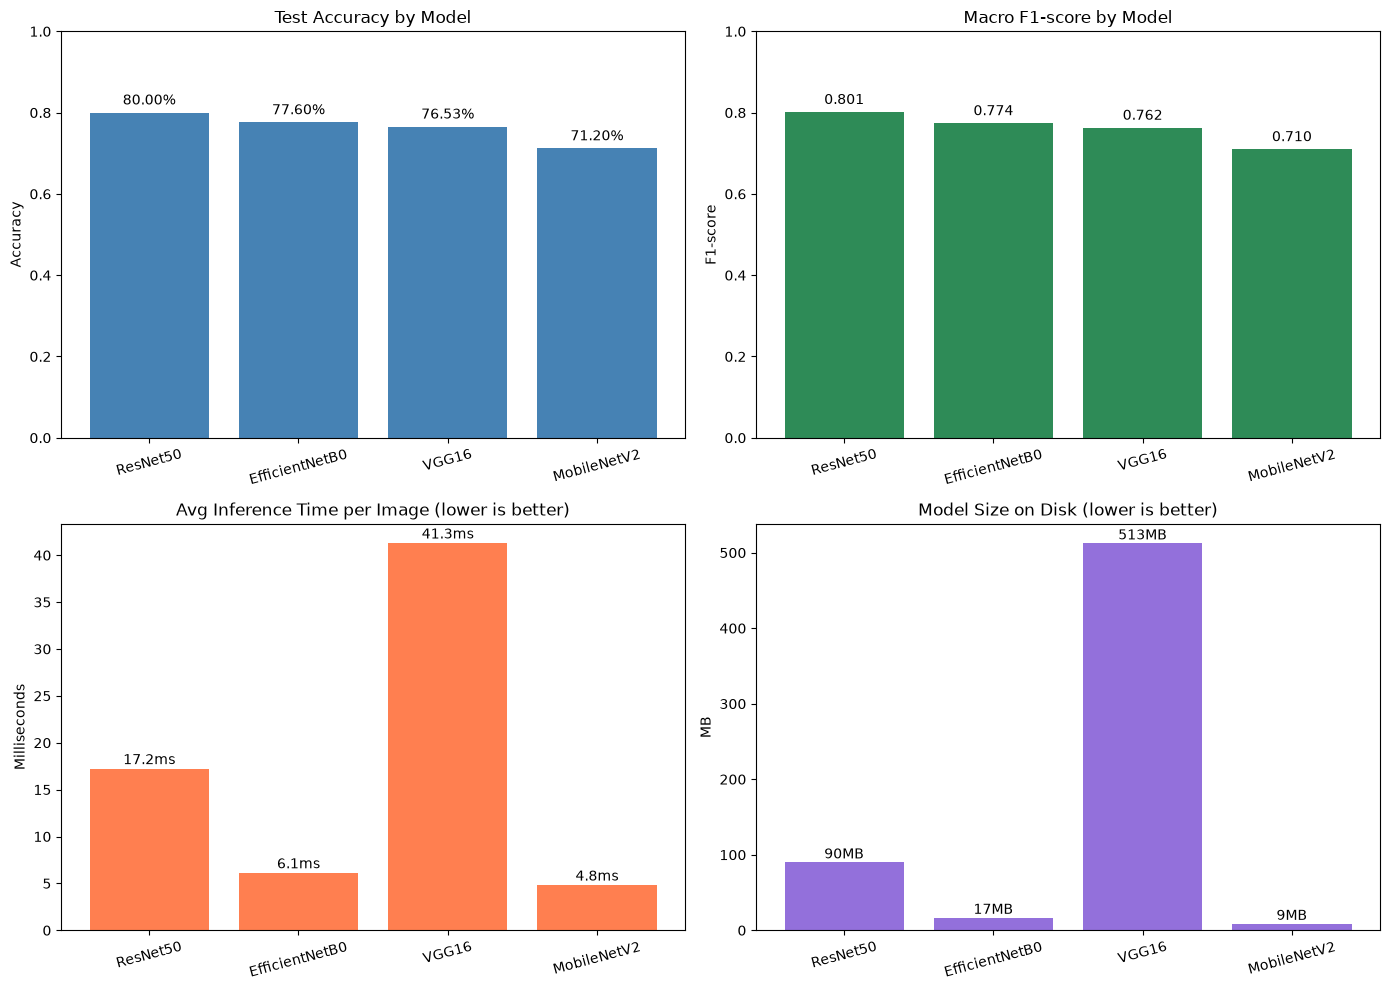

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy comparison
axes[0, 0].bar(comparison_df["Model"], comparison_df["Test Accuracy"], color="steelblue")
axes[0, 0].set_title("Test Accuracy by Model")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].set_ylim(0, 1)
for i, v in enumerate(comparison_df["Test Accuracy"]):
    axes[0, 0].text(i, v + 0.02, f"{v:.2%}", ha="center")

# F1-score comparison
axes[0, 1].bar(comparison_df["Model"], comparison_df["F1-score (macro)"], color="seagreen")
axes[0, 1].set_title("Macro F1-score by Model")
axes[0, 1].set_ylabel("F1-score")
axes[0, 1].set_ylim(0, 1)
for i, v in enumerate(comparison_df["F1-score (macro)"]):
    axes[0, 1].text(i, v + 0.02, f"{v:.3f}", ha="center")

# Inference time comparison
axes[1, 0].bar(comparison_df["Model"], comparison_df["Avg Inference Time (ms)"], color="coral")
axes[1, 0].set_title("Avg Inference Time per Image (lower is better)")
axes[1, 0].set_ylabel("Milliseconds")
for i, v in enumerate(comparison_df["Avg Inference Time (ms)"]):
    axes[1, 0].text(i, v + 0.5, f"{v:.1f}ms", ha="center")

# Model size comparison
axes[1, 1].bar(comparison_df["Model"], comparison_df["Model Size (MB)"], color="mediumpurple")
axes[1, 1].set_title("Model Size on Disk (lower is better)")
axes[1, 1].set_ylabel("MB")
for i, v in enumerate(comparison_df["Model Size (MB)"]):
    axes[1, 1].text(i, v + 5, f"{v:.0f}MB", ha="center")

for ax in axes.flatten():
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig("../results/eda_plots/model_comparison.png")
plt.show()

In [9]:
# Accuracy-speed-size tradeoff scoring for final selection
import json
print("=" * 70)
print("MODEL SELECTION SUMMARY")
print("=" * 70)
print(comparison_df.to_string(index=False))
print("=" * 70)

print("""
Analysis:
- ResNet50 has the highest raw accuracy (80.0%) and F1 (0.801), but is the
  2nd largest model (90MB) and 2nd slowest (17.2ms/image).
- EfficientNetB0 is a close second in accuracy (77.6%, -2.4pts vs ResNet50)
  while being 2.8x faster (6.1ms vs 17.2ms) and 5.3x smaller (17MB vs 90MB).
- VGG16 is dominated on every axis: mediocre accuracy (76.5%) but by far
  the slowest (41.3ms) and largest (513MB) — worst deployment candidate.
- MobileNetV2 is fastest (4.8ms) and smallest (9MB) but has the lowest
  accuracy (71.2%) — best only for extreme resource-constrained scenarios.

Recommendation: EfficientNetB0 as the primary deployed model — best
accuracy-to-efficiency tradeoff for a cloud-hosted Streamlit app on
Hugging Face Spaces (limited free-tier compute/memory). ResNet50 kept
as the "high-accuracy" alternative option in the app for users who
prioritize precision over speed.
""")

selection = {
    "primary_model": "EfficientNetB0",
    "primary_reason": "Best accuracy-to-efficiency tradeoff (77.6% acc, 6.1ms inference, 17MB)",
    "alternative_model": "ResNet50",
    "alternative_reason": "Highest raw accuracy (80.0%) for users prioritizing precision over speed",
    "not_recommended": "VGG16 (dominated on speed and size for similar accuracy)"
}

with open("../results/model_selection.json", "w") as f:
    json.dump(selection, f, indent=2)
print("Saved selection rationale to ../results/model_selection.json")

MODEL SELECTION SUMMARY
         Model  Test Accuracy  Top-5 Accuracy  Precision (macro)  Recall (macro)  F1-score (macro)  Avg Inference Time (ms)  Model Size (MB)
      ResNet50         0.8000          0.9440             0.8262          0.8000            0.8012                    17.22            90.17
EfficientNetB0         0.7760          0.9200             0.7940          0.7760            0.7737                     6.11            16.85
         VGG16         0.7653          0.9387             0.7751          0.7653            0.7625                    41.28           512.57
   MobileNetV2         0.7120          0.9280             0.7329          0.7120            0.7098                     4.80             8.84

Analysis:
- ResNet50 has the highest raw accuracy (80.0%) and F1 (0.801), but is the
  2nd largest model (90MB) and 2nd slowest (17.2ms/image).
- EfficientNetB0 is a close second in accuracy (77.6%, -2.4pts vs ResNet50)
  while being 2.8x faster (6.1ms vs 17.2ms) and 5.